In [89]:
print("\n==============================")
print(" AMAZON SALES DATA ANALYSIS PROJECT")
print("==============================\n")

print("\n===== 1. DATA LOADING =====\n")
print("Loading dataset from CSV file...\n")

print("\n===== 2. DATA UNDERSTANDING =====\n")
print("Understanding structure, columns, and basic information...\n")

print("\n===== 3. DATA CLEANING =====\n")
print("Handling missing values, fixing column names, and preprocessing...\n")

print("\n===== 4. SALES OVERVIEW =====\n")
print("Analyzing total revenue, orders, and sales trends...\n")

print("\n===== 5. PRODUCT ANALYSIS =====\n")
print("Analyzing product categories, sizes, and quantities...\n")

print("\n===== 6. FULFILLMENT ANALYSIS =====\n")
print("Analyzing fulfillment methods and delivery performance...\n")

print("\n===== 7. CUSTOMER SEGMENTATION =====\n")
print("Segmenting customers based on behavior, location, and value...\n")

print("\n===== 8. GEOGRAPHICAL ANALYSIS =====\n")
print("Analyzing sales across different states and cities...\n")

print("\n===== 9. BUSINESS INSIGHTS =====\n")
print("Extracting key insights from the data...\n")

print("\n===== 10. RECOMMENDATIONS =====\n")
print("Providing actionable business recommendations...\n")

print("\n===== 11. MACHINE LEARNING (OPTIONAL) =====\n")
print("Cancellation prediction using Logistic Regression...\n")

print("\n===== 12. FINAL CONCLUSION =====\n")
print("Summarizing how data analysis and machine learning can improve sales performance and business efficiency...\n")

print("\n==============================\n")





 AMAZON SALES DATA ANALYSIS PROJECT


===== 1. DATA LOADING =====

Loading dataset from CSV file...


===== 2. DATA UNDERSTANDING =====

Understanding structure, columns, and basic information...


===== 3. DATA CLEANING =====

Handling missing values, fixing column names, and preprocessing...


===== 4. SALES OVERVIEW =====

Analyzing total revenue, orders, and sales trends...


===== 5. PRODUCT ANALYSIS =====

Analyzing product categories, sizes, and quantities...


===== 6. FULFILLMENT ANALYSIS =====

Analyzing fulfillment methods and delivery performance...


===== 7. CUSTOMER SEGMENTATION =====

Segmenting customers based on behavior, location, and value...


===== 8. GEOGRAPHICAL ANALYSIS =====

Analyzing sales across different states and cities...


===== 9. BUSINESS INSIGHTS =====

Extracting key insights from the data...


===== 10. RECOMMENDATIONS =====

Providing actionable business recommendations...


===== 11. MACHINE LEARNING (OPTIONAL) =====

Cancellation prediction us

In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [8]:
print("\n===== 1. Data Loading =====\n")

df=pd.read_csv('/content/drive/MyDrive/Data Analytics Project/Amazon Sale Report.csv', encoding="latin1", engine="python")
df.head()



===== 1. Data Loading =====



,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [9]:
print("\n===== 2. Data Understanding =====\n")

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print(df.info())



===== 2. Data Understanding =====

Shape of dataset: (128976, 21)

Columns:
 Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

Data types:
 index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Category               object
Size                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
B2B                      bool
fulfilled-by           object
New                   f

In [10]:
print("\n===== 3. Data Cleaning =====\n")

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})
missing_df[missing_df["Missing Values"] > 0]


===== 3. Data Cleaning =====



,Missing Values,Percentage
Amount,7800,6.047637
New,128976,100.000000
PendingS,128976,100.000000
currency,7800,6.047637
fulfilled-by,89713,69.557902
ship-city,35,0.027137
ship-country,35,0.027137
ship-postal-code,35,0.027137
ship-state,35,0.027137


In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
print(df.columns.tolist())


print(df.columns)

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print(df.isnull().sum())

df['amount'] = df['amount'].fillna(df['amount'].median())
df['ship_city'] = df['ship_city'].fillna("Unknown")
df['ship_state'] = df['ship_state'].fillna("INR")
df['currency'] = df['currency'].fillna("Unknown")
df['ship_country'] = df['ship_country'].fillna("Unknown")
df['ship_postal_code'] = df['ship_postal_code'].fillna(0)
df['fulfilled_by'] = df['fulfilled_by'].fillna("Unknown")

df = df.drop(columns=['new', 'pendings'])

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()



df.info()

['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'category', 'size', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'b2b', 'fulfilled_by', 'new', 'pendings']
Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'category', 'size', 'courier_status', 'qty',
       'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code',
       'ship_country', 'b2b', 'fulfilled_by', 'new', 'pendings'],
      dtype='object')
Duplicate rows: 168
index                      0
order_id                   0
date                       0
status                     0
fulfilment                 0
sales_channel              0
ship_service_level         0
category                   0
size                       0
courier_status             0
qty                        0
currency                7789
amount                  7789
ship_city              

In [12]:
df.isnull().sum()
print(df.shape)

if "status" in df.columns:
    df["status"] = df["status"].astype(str).str.strip().str.title()
df.describe(include="all")


(128808, 24)


,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,year,month,month_name,day,day_name
count,128808.000000,128808,128808,128808,128808,128808,128808,128808,128808,128808,128808.000000,128808,128808.000000,128808,128808,128808.000000,128808,128808,128808,128808.0,128808.000000,128808,128808.000000,128808
unique,NaN,120229,NaN,13,2,2,2,9,11,4,NaN,2,NaN,8949,70,NaN,2,2,2,NaN,NaN,4,NaN,7
top,NaN,171-5057375-2831560,NaN,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,NaN,INR,NaN,BENGALURU,MAHARASHTRA,NaN,IN,False,Unknown,NaN,NaN,April,NaN,Sunday
freq,NaN,12,NaN,77713,89595,128684,88513,50219,22350,109341,NaN,121019,NaN,11191,22234,NaN,128775,127937,89595,NaN,NaN,48900,NaN,19619
mean,64564.582906,NaN,2022-05-12 12:17:48.529904896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.904416,NaN,645.993505,NaN,NaN,463838.207464,NaN,NaN,NaN,2022.0,4.910370,NaN,14.909920,NaN
min,0.000000,NaN,2022-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,2022.0,3.000000,NaN,1.000000,NaN
25%,32368.750000,NaN,2022-04-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,459.000000,NaN,NaN,382421.000000,NaN,NaN,NaN,2022.0,4.000000,NaN,7.000000,NaN
50%,64570.500000,NaN,2022-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,605.000000,NaN,NaN,500033.000000,NaN,NaN,NaN,2022.0,5.000000,NaN,15.000000,NaN
75%,96772.250000,NaN,2022-06-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,771.000000,NaN,NaN,600024.000000,NaN,NaN,NaN,2022.0,6.000000,NaN,22.000000,NaN
max,128974.000000,NaN,2022-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,5584.000000,NaN,NaN,989898.000000,NaN,NaN,NaN,2022.0,6.000000,NaN,31.000000,NaN


In [13]:
print("\n===== 4. Sales Overview =====\n")

total_orders = df['order_id'].nunique()
total_revenue = df['amount'].sum()
total_quantity = df['qty'].sum()
avg_order_value = df['amount'].mean()

print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", avg_order_value)

monthly_sales = df.groupby('month_name')['amount'].sum().sort_values(ascending=False)
print(monthly_sales)


===== 4. Sales Overview =====

Total Orders: 120229
Total Revenue: 83209131.39000002
Total Quantity Sold: 116496
Average Order Value: 645.9935049841625
month_name
April    30553581.41
May      27741396.75
June     24807024.38
March      107128.85
Name: amount, dtype: float64


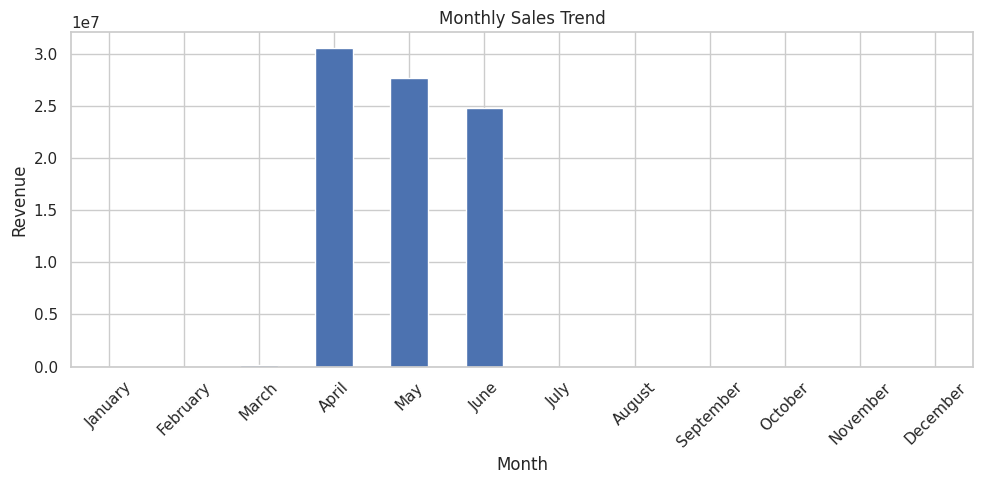

In [14]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

monthly_sales = df.groupby('month_name')['amount'].sum()
monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

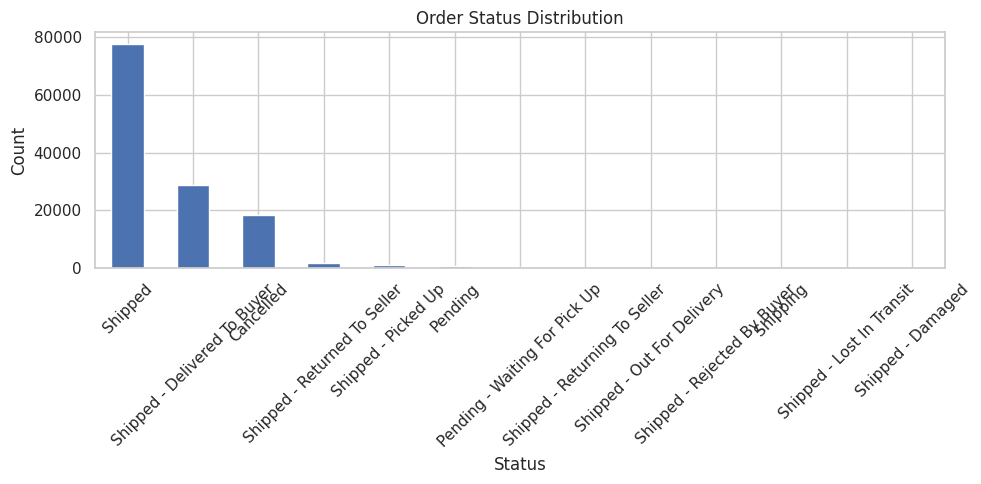

In [15]:
df['status'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


===== 5. Product Analysis =====



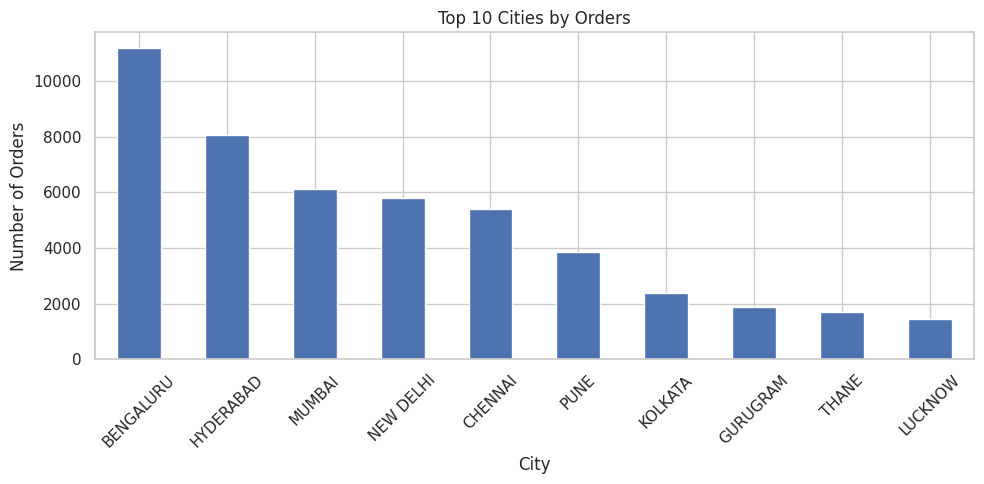

In [16]:
# Univariate Analysis - Categorical Data
# ship_city

print("\n===== 5. Product Analysis =====\n")


df['ship_city'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


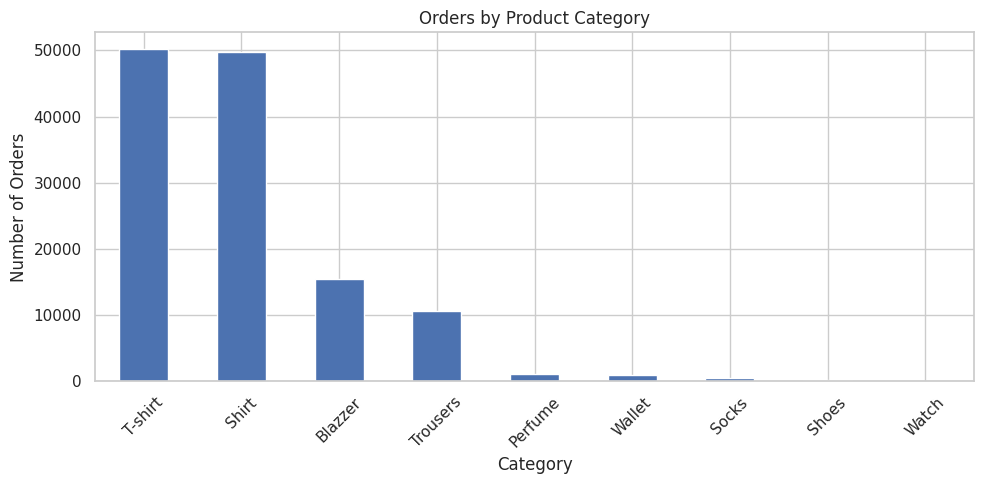

In [17]:
df['category'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Orders by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='ship_state'>

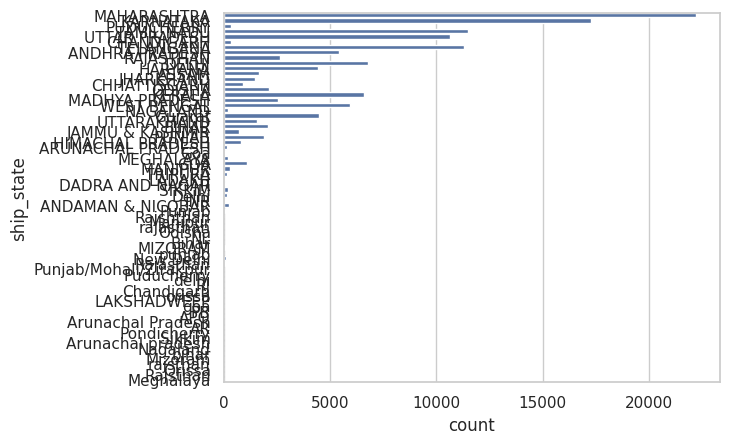

In [18]:
sns.countplot(df["ship_state"])

In [19]:
# KPI Section(Main KPIs)

total_orders = len(df)

total_revenue = df["amount"].sum() if "amount" in df.columns else 0
total_qty = df["qty"].sum() if "qty" in df.columns else 0
avg_order_value = total_revenue / total_orders if total_orders > 0 else 0
avg_qty_per_order = total_qty / total_orders if total_orders > 0 else 0

print("Total Orders:", total_orders)
print("Total Revenue:", round(total_revenue, 2))
print("Total Quantity Sold:", round(total_qty, 2))
print("Average Order Value:", round(avg_order_value, 2))
print("Average Quantity per Order:", round(avg_qty_per_order, 2))

Total Orders: 128808
Total Revenue: 83209131.39
Total Quantity Sold: 116496
Average Order Value: 645.99
Average Quantity per Order: 0.9


In [20]:
if "status" in df.columns:
    shipped_orders = df[df["status"] == "Shipped"].shape[0]
    shipped_rate = (shipped_orders / total_orders) * 100
    print("Shipped Order Rate:", round(shipped_rate,2), "%")

Shipped Order Rate: 60.33 %


In [21]:
if "category" in df.columns:
    category_sales = df.groupby("category")["amount"].sum().sort_values(ascending=False)
    print(category_sales.head(10))

category
T-shirt     41113727.17
Shirt       23180963.70
Blazzer     11689481.12
Trousers     5617185.30
Perfume       829349.66
Wallet        485633.18
Socks         162497.50
Shoes         129378.76
Watch            915.00
Name: amount, dtype: float64


In [22]:
if "ship_state" in df.columns:
    state_sales = df.groupby("ship_state")["amount"].sum().sort_values(ascending=False)
    print(state_sales.head(10))

ship_state
MAHARASHTRA       14036496.38
KARNATAKA         11029247.03
TELANGANA          7328935.08
UTTAR PRADESH      7231576.08
TAMIL NADU         6918273.73
DELHI              4463848.97
KERALA             4084567.58
WEST BENGAL        3754298.44
ANDHRA PRADESH     3441734.86
HARYANA            3015271.99
Name: amount, dtype: float64


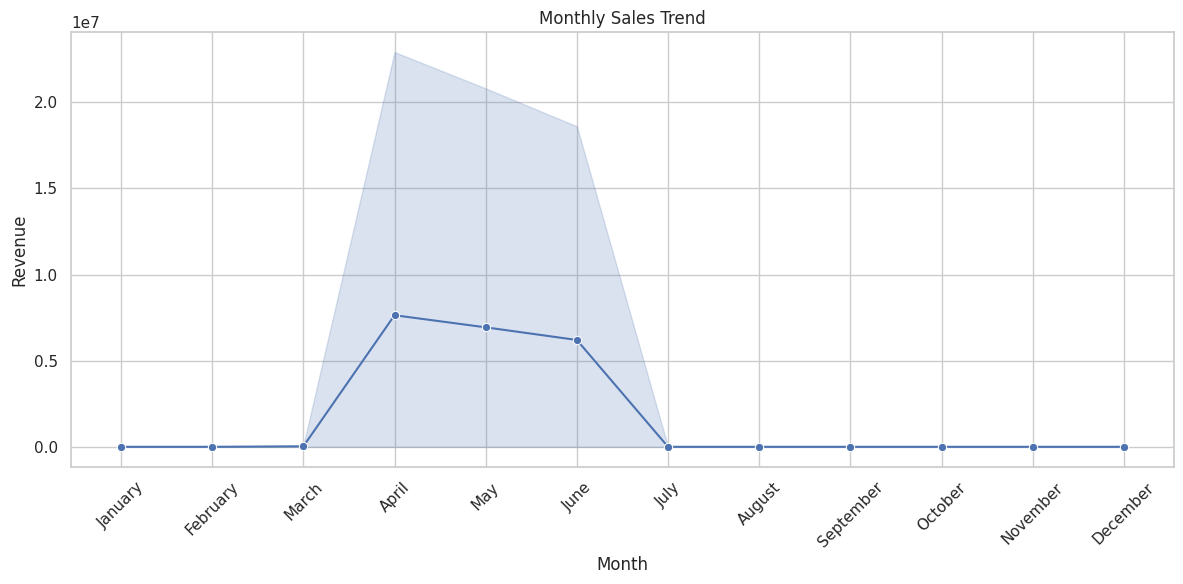

In [23]:
# EDA Visualization Section
    # Monthly sales trend.

if "month_name" in df.columns and "amount" in df.columns and "month" in df.columns:
    monthly_sales = df.groupby(["month", "month_name"])["amount"].sum().reset_index()
    monthly_sales = monthly_sales.sort_values("month")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=monthly_sales, x="month_name", y="amount", marker="o")
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

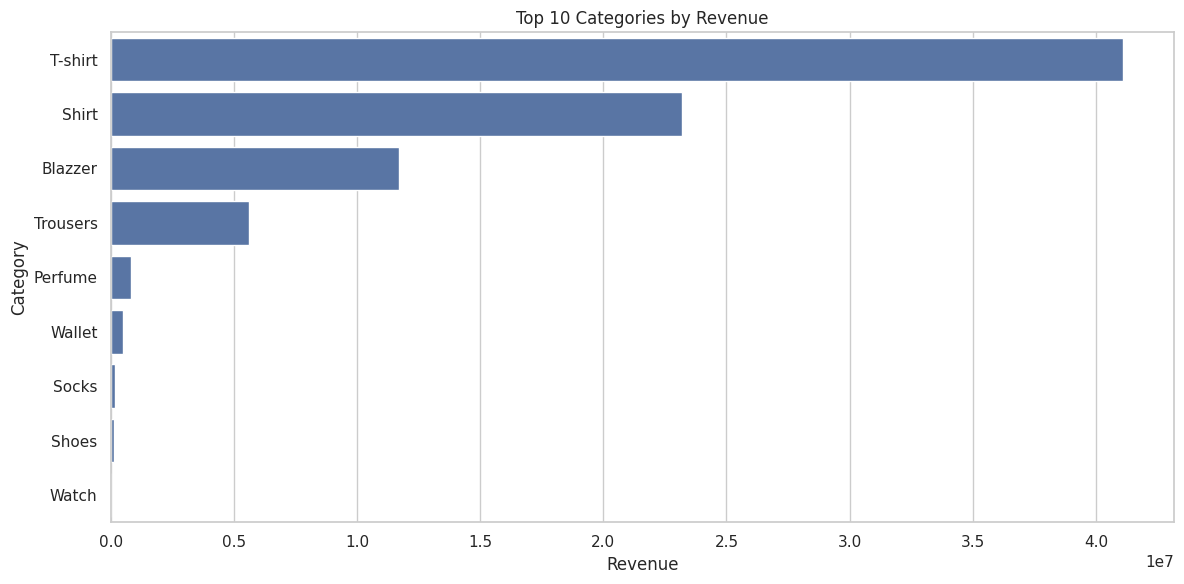

In [24]:
# Top 10 categories by revenue
if "category" in df.columns and "amount" in df.columns:
    top_categories = df.groupby("category")["amount"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_categories.values, y=top_categories.index)
    plt.title("Top 10 Categories by Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

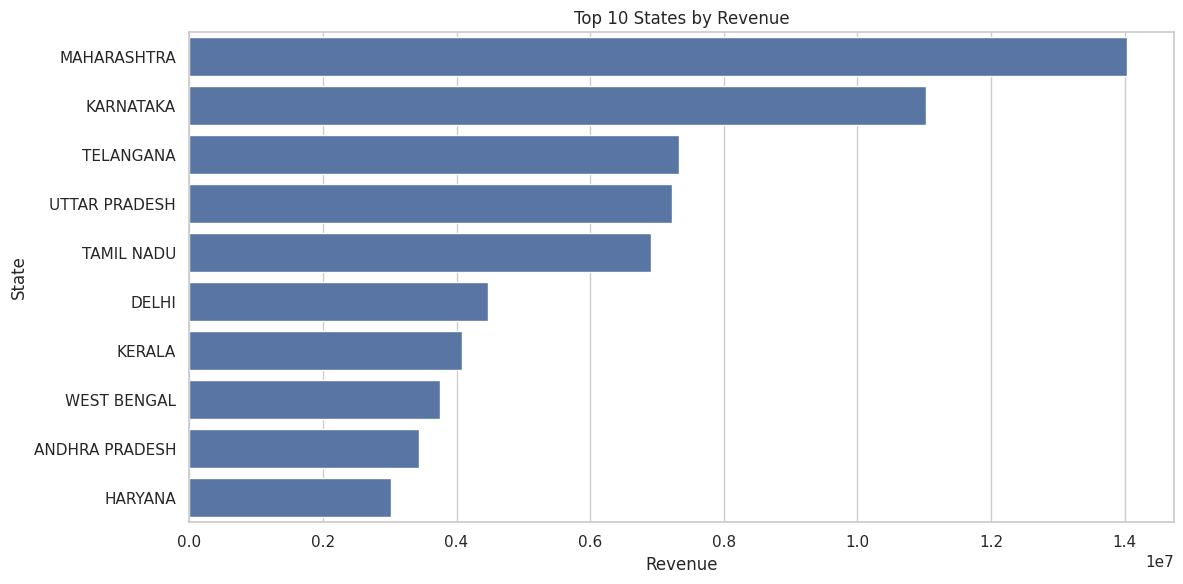

In [25]:
# Top 10 states by revenue
if "ship_state" in df.columns and "amount" in df.columns:
    top_states = df.groupby("ship_state")["amount"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_states.values, y=top_states.index)
    plt.title("Top 10 States by Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show()

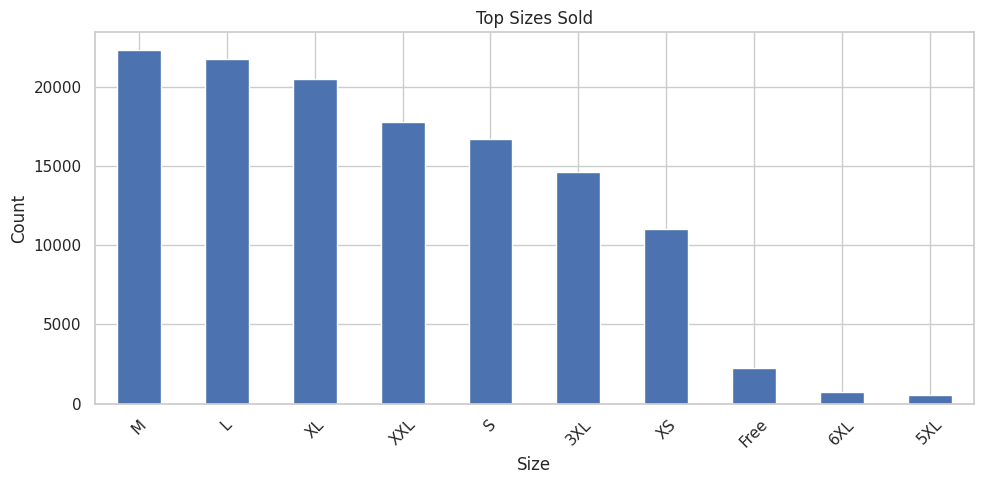

In [26]:
# Size analysis

df['size'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top Sizes Sold")
plt.xlabel("Size")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

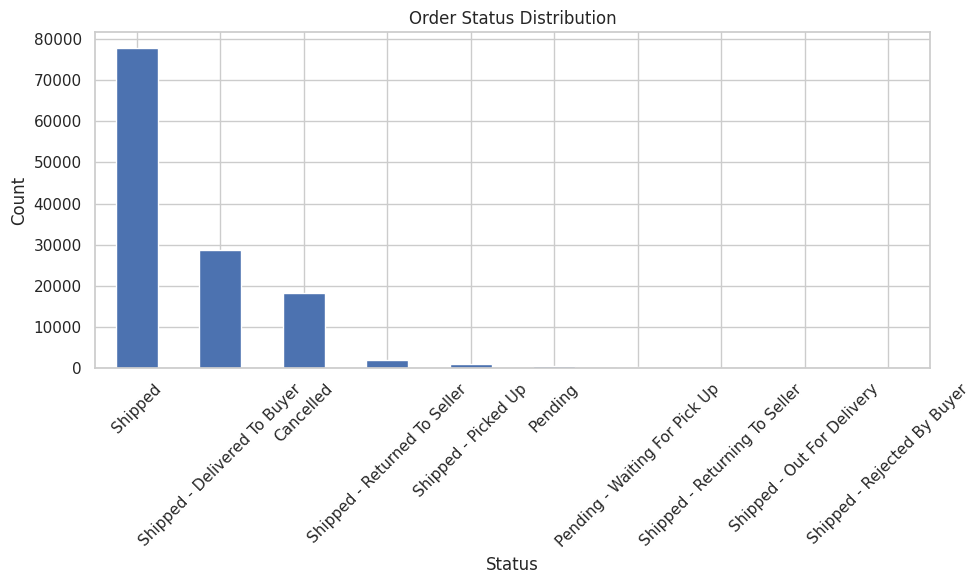

In [27]:
# Order status distribution

if "status" in df.columns:
    plt.figure(figsize=(10, 6))
    df["status"].value_counts().head(10).plot(kind="bar")
    plt.title("Order Status Distribution")
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

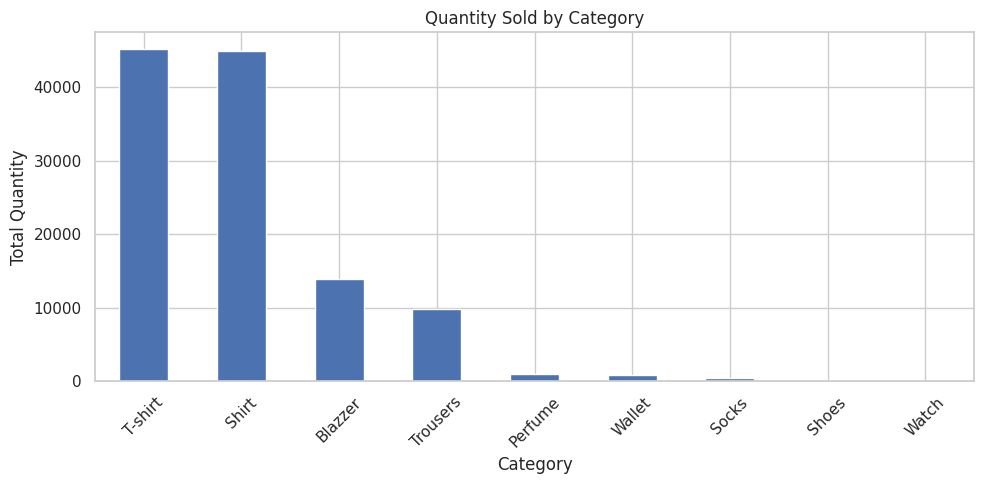

In [28]:
# Quantity by category

qty_by_category = df.groupby('category')['qty'].sum().sort_values(ascending=False)
qty_by_category.plot(kind='bar', figsize=(10,5))
plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


===== 6. Fulfillment Analysis =====



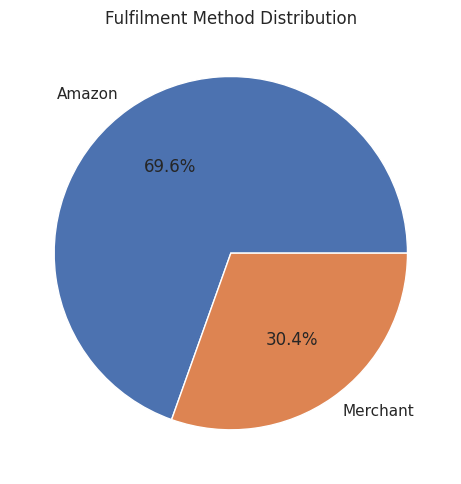

In [29]:
# Fulfilment analysis
print("\n===== 6. Fulfillment Analysis =====\n")

if "fulfilment" in df.columns:
    plt.figure(figsize=(8, 5))
    df["fulfilment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title("Fulfilment Method Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

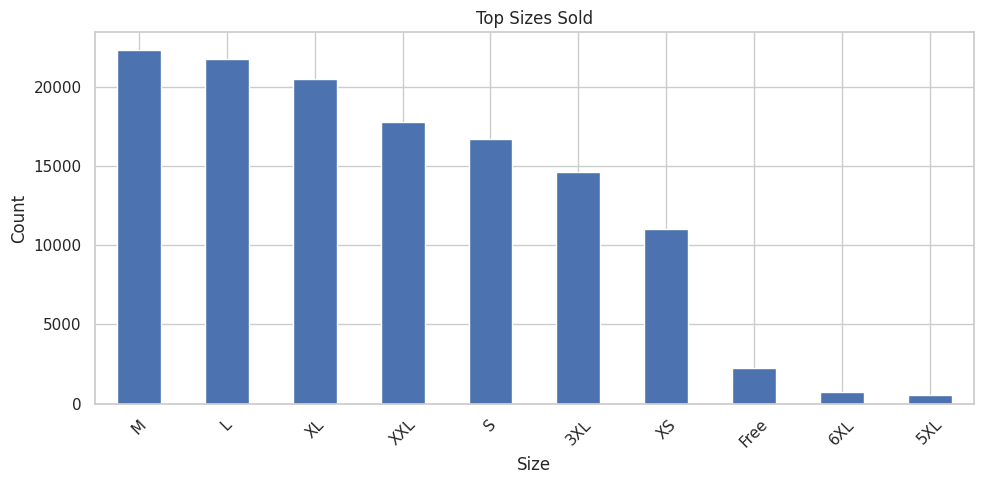

In [30]:
# Size analysis

if "size" in df.columns:
    plt.figure(figsize=(10, 5))
    df["size"].value_counts().head(10).plot(kind="bar")
    plt.title("Top Sizes Sold")
    plt.xlabel("Size")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

status      Cancelled  Pending  Pending - Waiting For Pick Up  Shipped  \
fulfilment                                                               
Amazon          11459      415                              0    77713   
Merchant         6852      243                            281        0   

status      Shipped - Damaged  Shipped - Delivered To Buyer  \
fulfilment                                                    
Amazon                      0                             0   
Merchant                    1                         28715   

status      Shipped - Lost In Transit  Shipped - Out For Delivery  \
fulfilment                                                          
Amazon                              0                           0   
Merchant                            5                          35   

status      Shipped - Picked Up  Shipped - Rejected By Buyer  \
fulfilment                                                     
Amazon                        0              

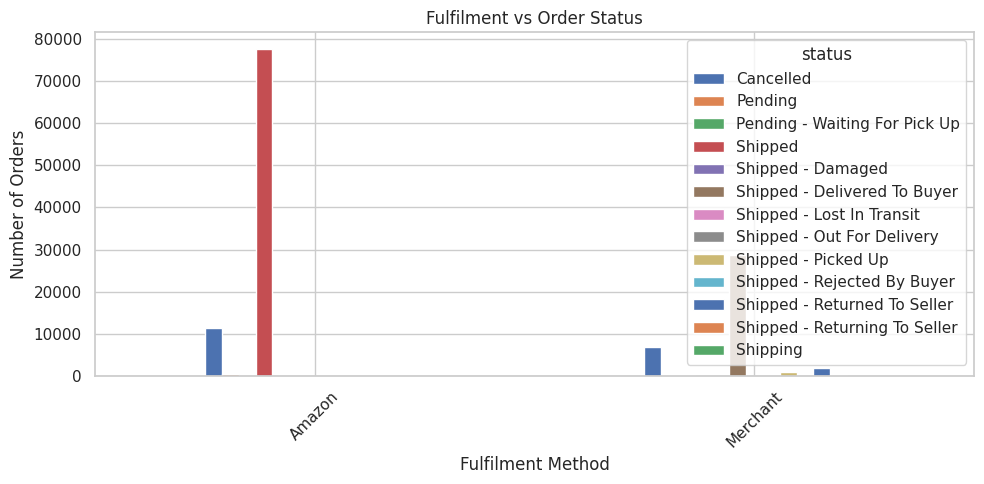

In [31]:
# Fulfilment vs status

fulfilment_status = pd.crosstab(df['fulfilment'], df['status'])
print(fulfilment_status)

fulfilment_status.plot(kind='bar', figsize=(10,5))
plt.title("Fulfilment vs Order Status")
plt.xlabel("Fulfilment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fulfilment
Amazon      0.127898
Merchant    0.174738
Name: status, dtype: float64


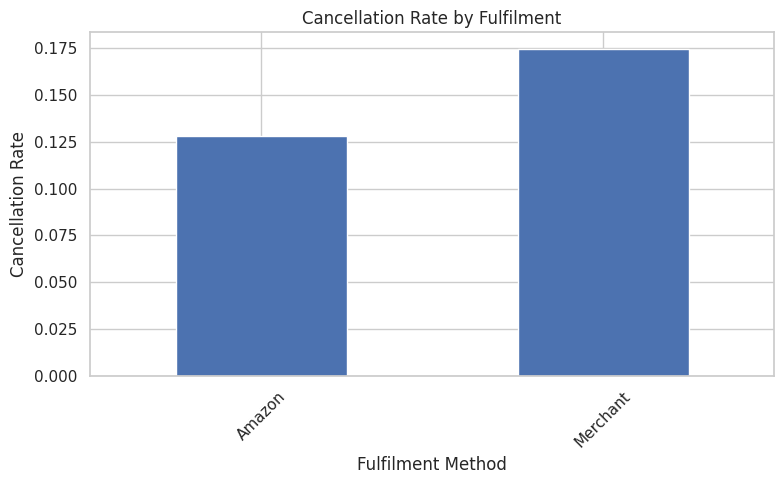

In [32]:
# Cancellation rate by fulfilment
cancel_rate = df.groupby('fulfilment')['status'].apply(lambda x: (x == "Cancelled").sum() / len(x))
print(cancel_rate)

cancel_rate.plot(kind='bar', figsize=(8,5))
plt.title("Cancellation Rate by Fulfilment")
plt.xlabel("Fulfilment Method")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fulfilment
Amazon      0.867381
Merchant    0.000000
Name: status, dtype: float64


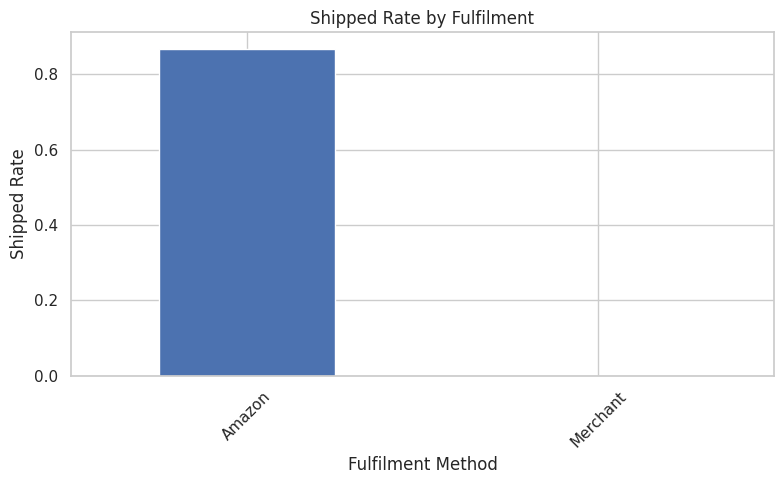

In [33]:
# Cancellation rate by fulfilment

shipped_rate = df.groupby('fulfilment')['status'].apply(lambda x: (x == "Shipped").sum() / len(x))
print(shipped_rate)

shipped_rate.plot(kind='bar', figsize=(8,5))
plt.title("Shipped Rate by Fulfilment")
plt.xlabel("Fulfilment Method")
plt.ylabel("Shipped Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

courier_status  Cancelled  On the Way  Shipped  Unshipped
fulfilment                                               
Amazon               5929           0    77515       6151
Merchant                0        6863    31826        524


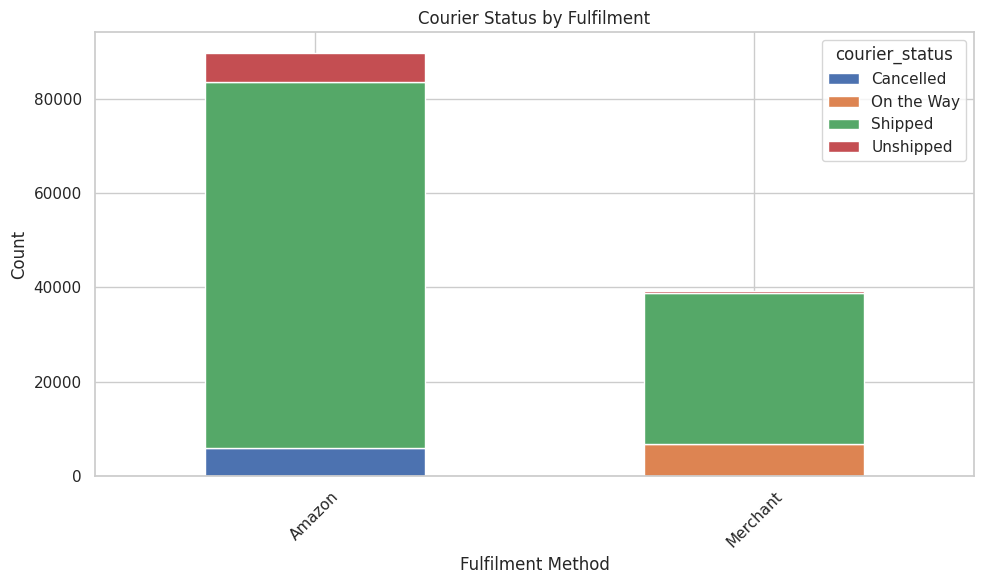

In [34]:
# Courier status by fulfilment

courier_analysis = pd.crosstab(df['fulfilment'], df['courier_status'])
print(courier_analysis)

courier_analysis.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Courier Status by Fulfilment")
plt.xlabel("Fulfilment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category           Blazzer  Perfume  Shirt  Shoes  Socks  T-shirt  Trousers  \
ship_state                                                                    
ANDAMAN & NICOBAR       32        0     94      0      1      118        11   
ANDHRA PRADESH         730       40   2574      3     18     1842       182   
APO                      0        0      0      0      0        1         0   
AR                       0        0      0      0      0        0         1   
ARUNACHAL PRADESH       20        1     16      0      1       63        40   

category           Wallet  Watch  
ship_state                        
ANDAMAN & NICOBAR       0      0  
ANDHRA PRADESH         32      0  
APO                     0      0  
AR                      0      0  
ARUNACHAL PRADESH       0      0  


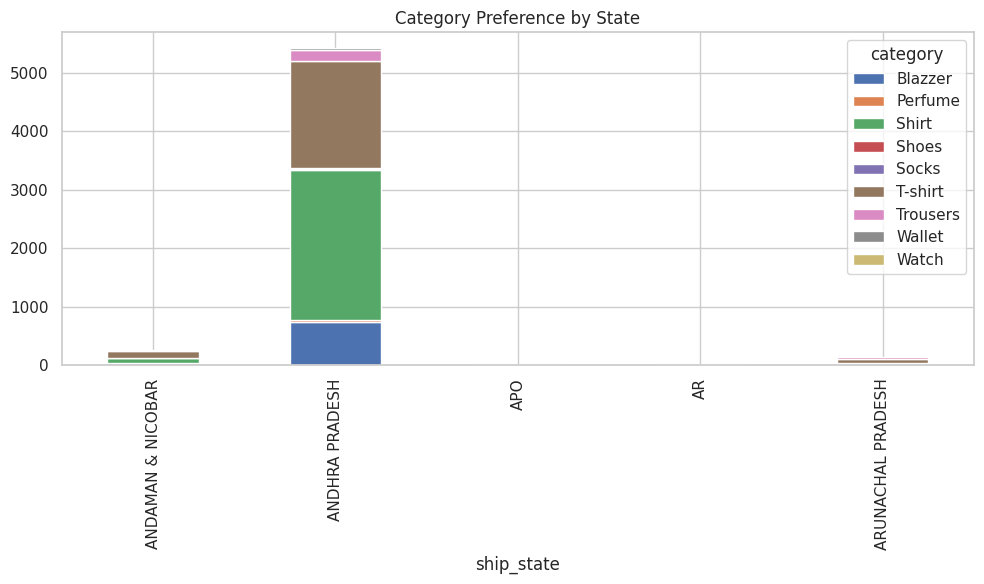

In [35]:
# Category preference by state

state_category = pd.crosstab(df['ship_state'], df['category'])
print(state_category.head())

state_category.head(5).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Category Preference by State")
plt.tight_layout()
plt.show()


===== 7. Customer Segmentation =====



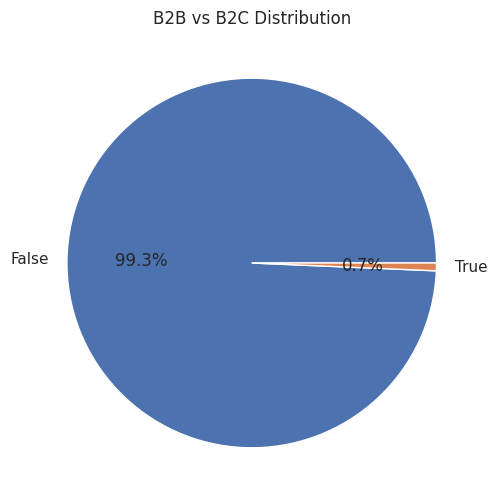

In [36]:
# B2B vs B2C
print("\n===== 7. Customer Segmentation =====\n")


df['b2b'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("B2B vs B2C Distribution")
plt.ylabel("")
plt.show()

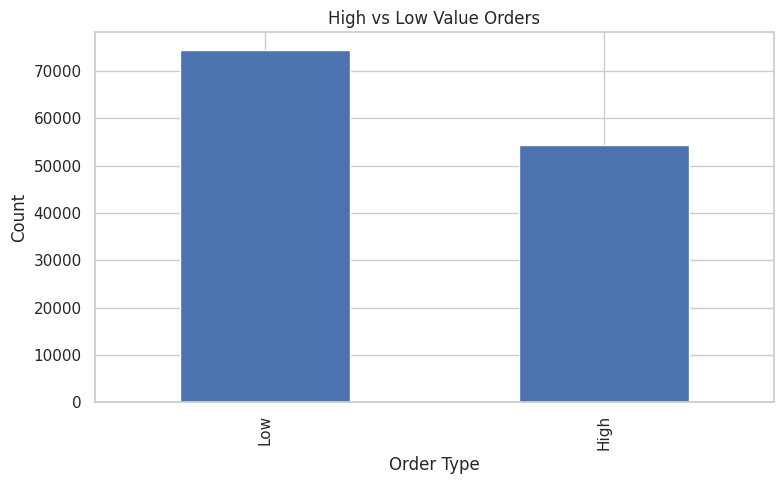

In [37]:
# High vs low value orders

avg_amount = df['amount'].mean()
df['amount_category'] = df['amount'].apply(lambda x: 'High' if x > avg_amount else 'Low')

df['amount_category'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("High vs Low Value Orders")
plt.xlabel("Order Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


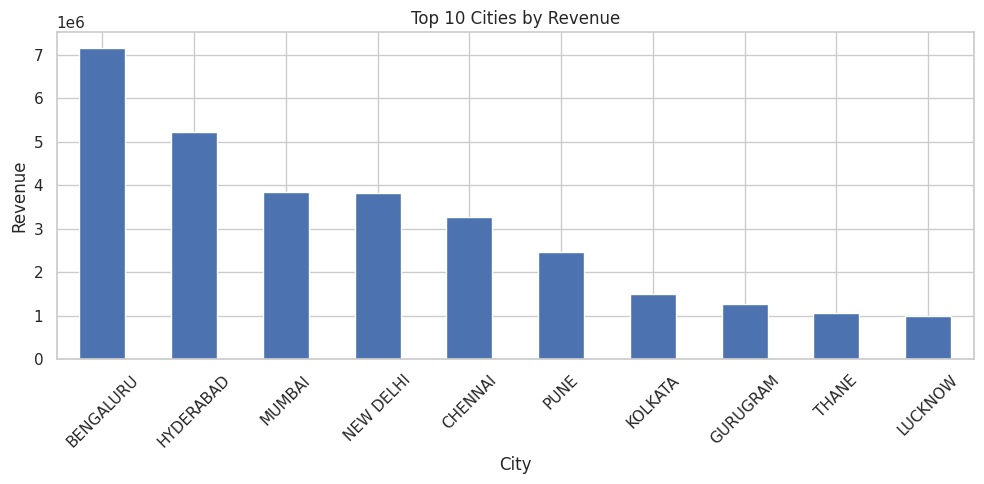

In [38]:
# Top cities by buying pattern

top_cities = df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

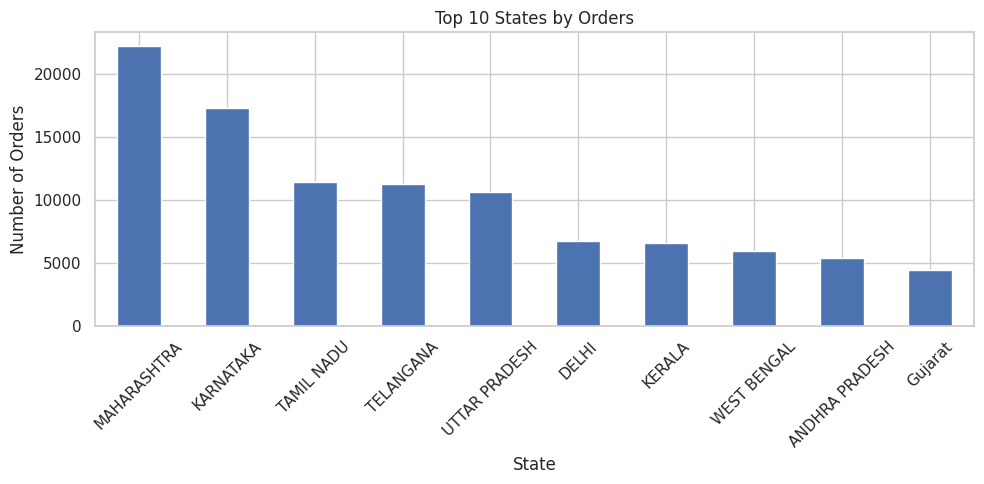

In [40]:
# State-wise customer distribution

state_customers = df['ship_state'].value_counts().head(10)
state_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Orders")
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ship_city
BENGALURU    7158474.65
HYDERABAD    5224930.25
MUMBAI       3853399.04
NEW DELHI    3817002.78
CHENNAI      3274800.74
PUNE         2458978.18
KOLKATA      1495095.87
GURUGRAM     1271987.74
THANE        1060748.29
LUCKNOW       996846.34
Name: amount, dtype: float64


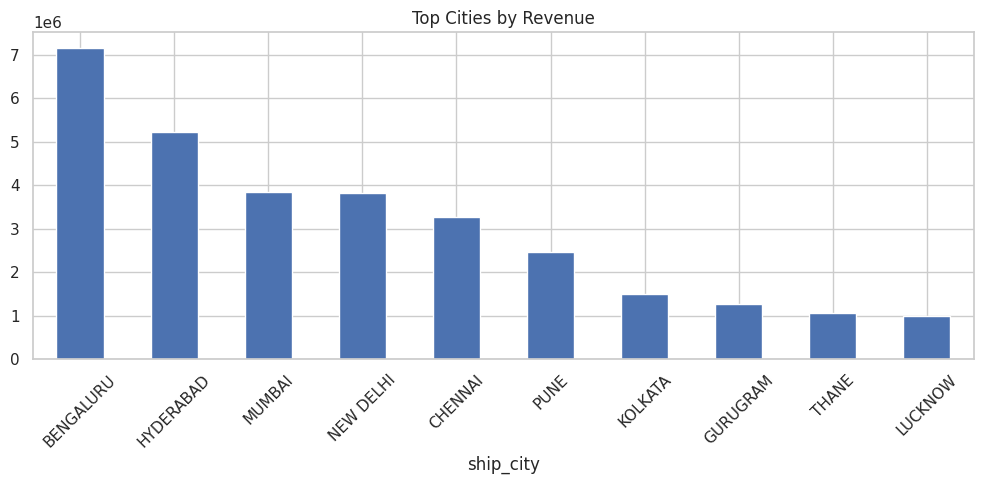

In [41]:
top_cities = df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10)
print(top_cities)

top_cities.plot(kind='bar', figsize=(10,5))
plt.title("Top Cities by Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

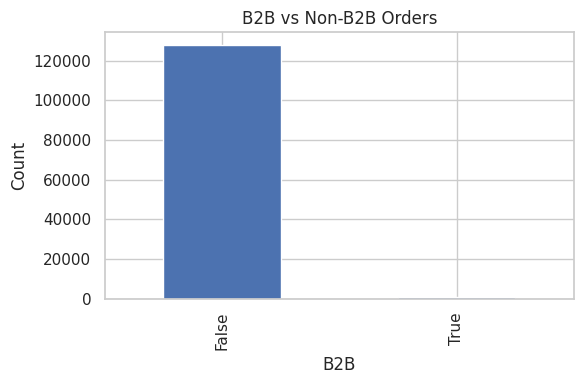

In [44]:
# B2B analysis

if "b2b" in df.columns:
    plt.figure(figsize=(6, 4))
    df["b2b"].value_counts().plot(kind="bar")
    plt.title("B2B vs Non-B2B Orders")
    plt.xlabel("B2B")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

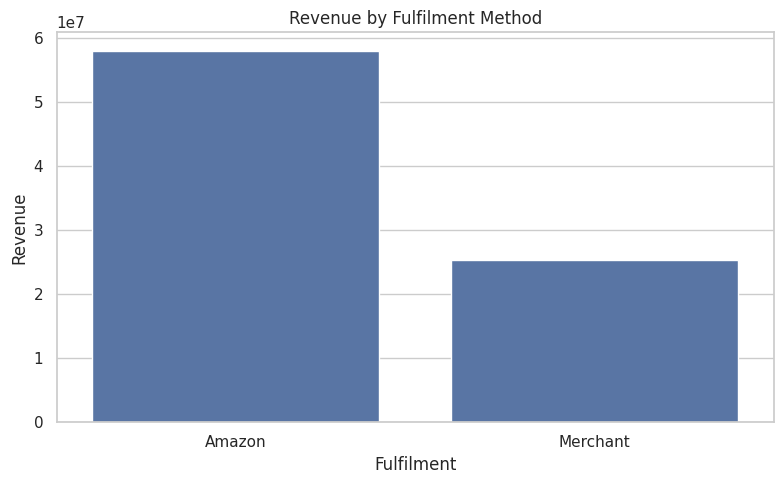

In [45]:
# Revenue by fulfilment

if "fulfilment" in df.columns and "amount" in df.columns:
    fulfilment_sales = df.groupby("fulfilment")["amount"].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=fulfilment_sales.index, y=fulfilment_sales.values)
    plt.title("Revenue by Fulfilment Method")
    plt.xlabel("Fulfilment")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()

In [46]:
# Cancellation analysis

if "status" in df.columns:
    cancelled_orders = df[df["status"].str.contains("Cancelled", case=False, na=False)]
    cancel_rate = (len(cancelled_orders) / len(df)) * 100
    print("Cancellation Rate:", round(cancel_rate, 2), "%")

Cancellation Rate: 14.22 %


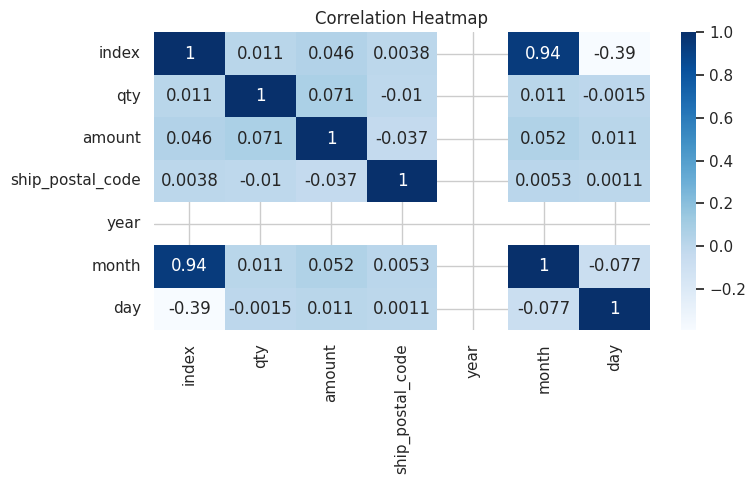

In [47]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    plt.figure(figsize=(8, 5))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


===== 8. Geographical Analysis =====



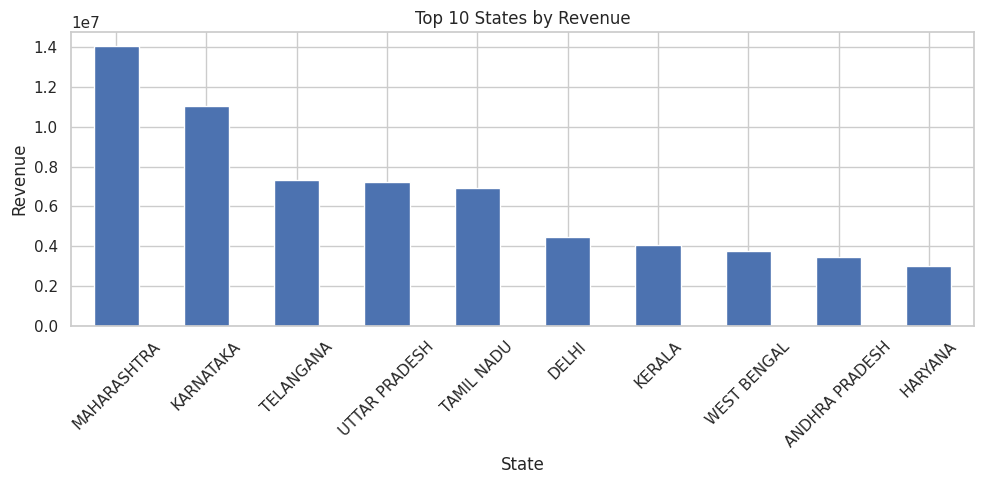

In [48]:
# Geographical Analysis
print("\n===== 8. Geographical Analysis =====\n")


state_revenue = df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10)
state_revenue.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

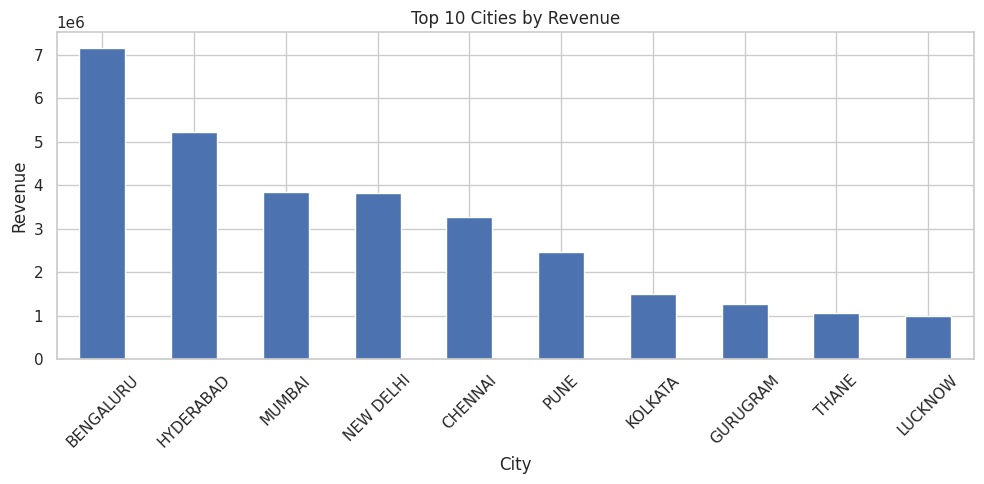

In [49]:
# Revenue by city

city_revenue = df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10)
city_revenue.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# Business insights section
   # Quick insight extraction

print("=====9. BUSINESS INSIGHTS =====")

if "category" in df.columns and "amount" in df.columns:
    top_category = df.groupby("category")["amount"].sum().idxmax()
    print("Top revenue generating category:", top_category)

if "ship_state" in df.columns and "amount" in df.columns:
    top_state = df.groupby("ship_state")["amount"].sum().idxmax()
    print("Top revenue generating state:", top_state)

if "month_name" in df.columns and "amount" in df.columns and "month" in df.columns:
    monthly_sales = df.groupby(["month", "month_name"])["amount"].sum().reset_index().sort_values("month")
    top_month = monthly_sales.loc[monthly_sales["amount"].idxmax(), "month_name"]
    print("Best sales month:", top_month)

if "status" in df.columns:
    print("Most common order status:", df["status"].mode()[0])

if "fulfilment" in df.columns:
    print("Most used fulfilment method:", df["fulfilment"].mode()[0])


print("Insight: T-shirt category has the highest sales volume.")

=====9. BUSINESS INSIGHTS =====
Top revenue generating category: T-shirt
Top revenue generating state: MAHARASHTRA
Best sales month: April
Most common order status: Shipped
Most used fulfilment method: Amazon
Insight: T-shirt category has the highest sales volume.


In [51]:
df.to_csv("cleaned_amazon_sales.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [52]:
from google.colab import files
files.download("cleaned_amazon_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
print("\n=====10. BUSINESS RECOMMENDATIONS =====\n")

print("1. Focus on Top-Selling Categories:")
print("   The analysis shows that certain product categories generate the highest revenue.")
print("   The company should maintain sufficient inventory and ensure availability of these products to maximize sales.\n")

print("2. Improve Performance in Low-Sales States:")
print("   Some states contribute less to overall revenue.")
print("   Targeted marketing campaigns and region-specific offers can help increase sales in these areas.\n")

print("3. Optimize Fulfillment Methods:")
print("   Fulfillment analysis indicates differences in delivery success and cancellation rates.")
print("   The company should prioritize fulfillment methods with higher successful delivery rates.\n")

print("4. Reduce Order Cancellations:")
print("   High cancellation rates negatively impact revenue and customer trust.")
print("   Improving delivery timelines and product availability can help reduce cancellations.\n")

print("5. Strengthen Courier Performance:")
print("   Courier status analysis shows inefficiencies in delivery for some orders.")
print("   Partnering with reliable courier services can improve delivery success rates.\n")

print("6. Focus on High-Value Customers:")
print("   High-value orders contribute significantly to overall revenue.")
print("   Personalized offers and loyalty programs can help retain these customers.\n")

print("7. Target High-Performing Cities:")
print("   Some cities generate a large portion of total revenue.")
print("   Increasing marketing efforts in these cities can further boost sales.\n")

print("8. Plan for Seasonal Demand:")
print("   Sales trends show peak periods during certain months.")
print("   The company should plan inventory and promotions accordingly to maximize profit.\n")


=====10. BUSINESS RECOMMENDATIONS =====

1. Focus on Top-Selling Categories:
   The analysis shows that certain product categories generate the highest revenue.
   The company should maintain sufficient inventory and ensure availability of these products to maximize sales.

2. Improve Performance in Low-Sales States:
   Some states contribute less to overall revenue.
   Targeted marketing campaigns and region-specific offers can help increase sales in these areas.

3. Optimize Fulfillment Methods:
   Fulfillment analysis indicates differences in delivery success and cancellation rates.
   The company should prioritize fulfillment methods with higher successful delivery rates.

4. Reduce Order Cancellations:
   High cancellation rates negatively impact revenue and customer trust.
   Improving delivery timelines and product availability can help reduce cancellations.

5. Strengthen Courier Performance:
   Courier status analysis shows inefficiencies in delivery for some orders.
   Partn

In [55]:
print("\n===== 11. MACHINE LEARNING (OPTIONAL) =====\n")



===== 11. MACHINE LEARNING (OPTIONAL) =====



In [56]:
# CUSTOMER SEGMENTATION

required_cols = ["amount", "qty", "b2b"]

for col in required_cols:
    print(col, "->", col in df.columns)

amount -> True
qty -> True
b2b -> True


In [57]:
seg_df = df[["amount", "qty", "b2b"]].copy()

seg_df["b2b"] = seg_df["b2b"].astype(int)

seg_df.head()

,amount,qty,b2b
0,647.62,0,0
1,406.00,1,0
2,329.00,1,1
3,753.33,0,0
4,574.00,1,0


In [58]:
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_df)

seg_scaled[:5]

array([[ 5.96252257e-03, -2.88608163e+00, -8.25108377e-02],
       [-8.79785475e-01,  3.05018516e-01, -8.25108377e-02],
       [-1.16205762e+00,  3.05018516e-01,  1.21196200e+01],
       [ 3.93481854e-01, -2.88608163e+00, -8.25108377e-02],
       [-2.63918976e-01,  3.05018516e-01, -8.25108377e-02]])

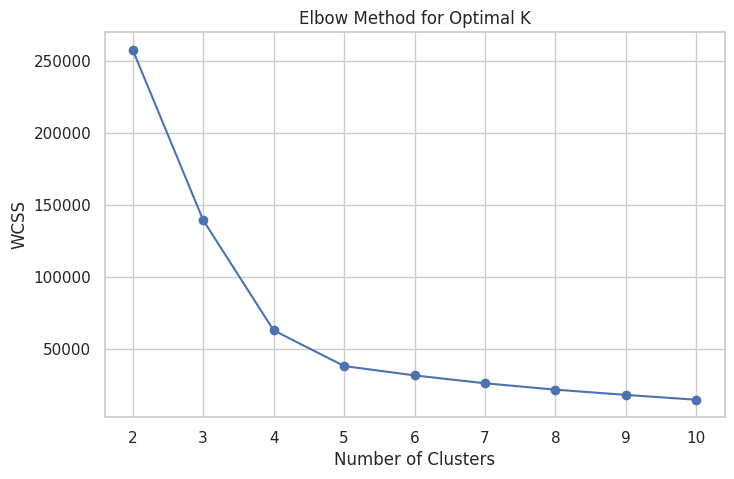

In [59]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(seg_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [62]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(seg_scaled)
    score = silhouette_score(seg_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.8761
K = 3, Silhouette Score = 0.6921
K = 4, Silhouette Score = 0.5980
K = 5, Silhouette Score = 0.6114
K = 6, Silhouette Score = 0.5555


In [63]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(seg_scaled)

df[["amount", "qty", "b2b", "cluster"]].head()

,amount,qty,b2b,cluster
0,647.62,0,False,2
1,406.00,1,False,0
2,329.00,1,True,1
3,753.33,0,False,2
4,574.00,1,False,0


In [64]:
cluster_summary = df.groupby("cluster")[["amount", "qty"]].mean().round(2)
cluster_count = df["cluster"].value_counts().sort_index()

print("Cluster Summary:\n")
print(cluster_summary)

print("\nCluster Counts:\n")
print(cluster_count)

Cluster Summary:

         amount   qty
cluster              
0        649.41  1.00
1        698.23  0.96
2        611.56  0.00

Cluster Counts:

cluster
0    115191
1       871
2     12746
Name: count, dtype: int64


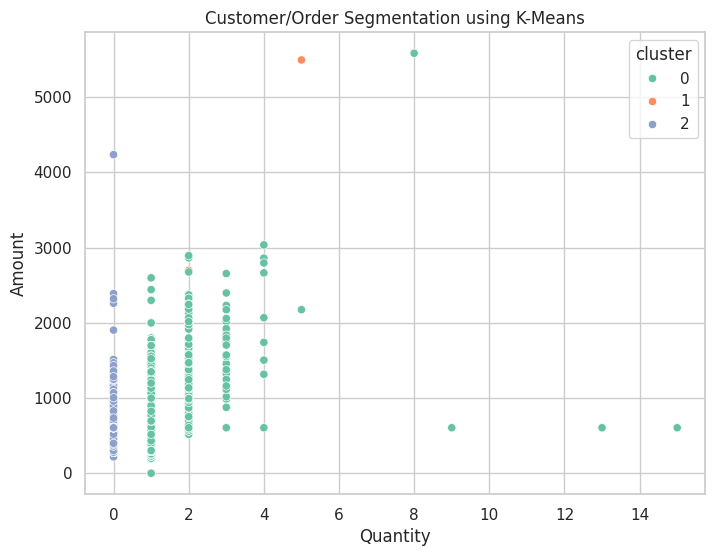

In [65]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="qty", y="amount", hue="cluster", palette="Set2")
plt.title("Customer/Order Segmentation using K-Means")
plt.xlabel("Quantity")
plt.ylabel("Amount")
plt.show()

In [66]:
cluster_insight = df.groupby("cluster")[["amount", "qty"]].mean().sort_values("amount")
cluster_insight

,amount,qty
cluster,,
2,611.561635,0.000000
0,649.408426,1.004037
1,698.232824,0.964409


In [67]:
df.to_csv("/content/amazon_sales_with_clusters.csv", index=False)
print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


In [68]:
# SALES FORECASTING

In [69]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

monthly_sales = df.groupby(pd.Grouper(key="date", freq="M"))["amount"].sum().reset_index()
monthly_sales.columns = ["date", "monthly_revenue"]

monthly_sales

,date,monthly_revenue
0,2022-03-31,107128.85
1,2022-04-30,30553581.41
2,2022-05-31,27741396.75
3,2022-06-30,24807024.38


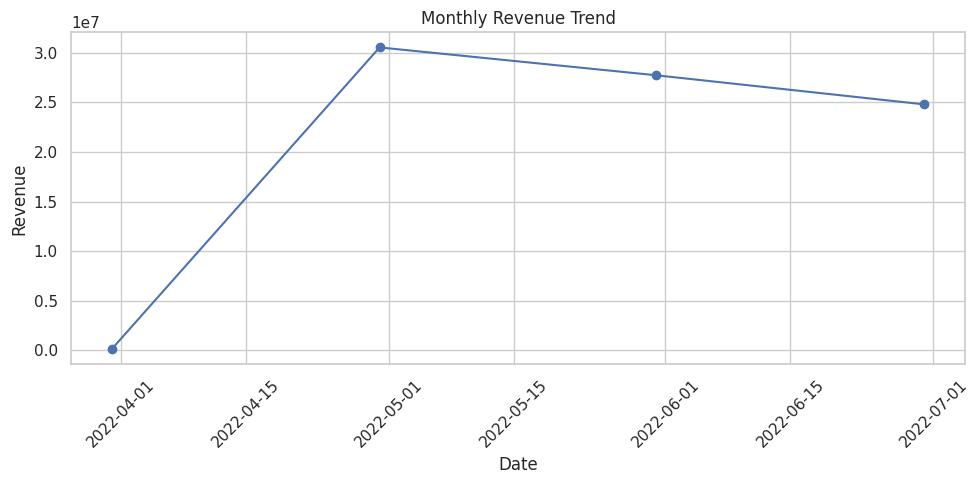

In [70]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["date"], monthly_sales["monthly_revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# Create time index
monthly_sales["month_index"] = range(1, len(monthly_sales) + 1)
monthly_sales

,date,monthly_revenue,month_index
0,2022-03-31,107128.85,1
1,2022-04-30,30553581.41,2
2,2022-05-31,27741396.75,3
3,2022-06-30,24807024.38,4


In [72]:
X = monthly_sales[["month_index"]]
y = monthly_sales["monthly_revenue"]

split_index = int(len(monthly_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3
Test size: 1


In [73]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression MAE: 22294612.523333322
Linear Regression RMSE: 22294612.523333322
Linear Regression R2 Score: nan


In [74]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest MAE: 2368192.5264
Random Forest RMSE: 2368192.5264
Random Forest R2 Score: nan


In [75]:
forecast_compare = pd.DataFrame({
    "date": monthly_sales["date"].iloc[split_index:].values,
    "actual": y_test.values,
    "linear_regression_pred": y_pred_lr,
    "random_forest_pred": y_pred_rf
})

forecast_compare

,date,actual,linear_regression_pred,random_forest_pred
0,2022-06-30,24807024.38,4.710164e+07,2.717522e+07


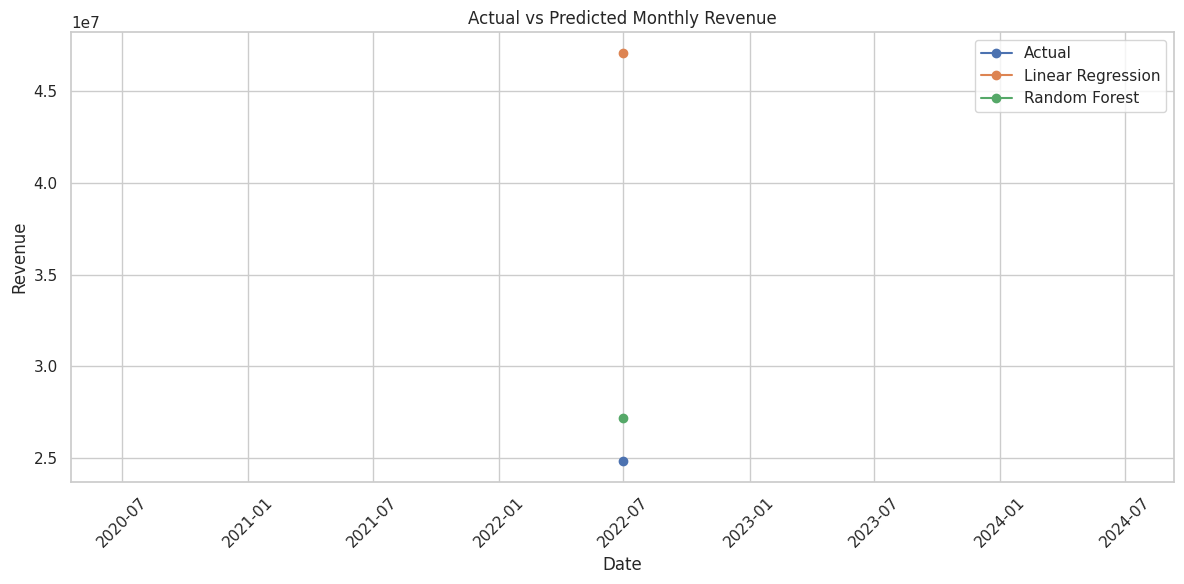

In [76]:
plt.figure(figsize=(12,6))
plt.plot(forecast_compare["date"], forecast_compare["actual"], marker='o', label="Actual")
plt.plot(forecast_compare["date"], forecast_compare["linear_regression_pred"], marker='o', label="Linear Regression")
plt.plot(forecast_compare["date"], forecast_compare["random_forest_pred"], marker='o', label="Random Forest")
plt.title("Actual vs Predicted Monthly Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# Future next 3 months prediction
future_index = pd.DataFrame({
    "month_index": range(len(monthly_sales) + 1, len(monthly_sales) + 4)
})

future_pred_lr = lr_model.predict(future_index)

future_dates = pd.date_range(start=monthly_sales["date"].max() + pd.offsets.MonthEnd(1), periods=3, freq="M")

future_forecast = pd.DataFrame({
    "date": future_dates,
    "predicted_revenue": future_pred_lr
})

future_forecast

,date,predicted_revenue
0,2022-07-31,6.091877e+07
1,2022-08-31,7.473590e+07
2,2022-09-30,8.855304e+07


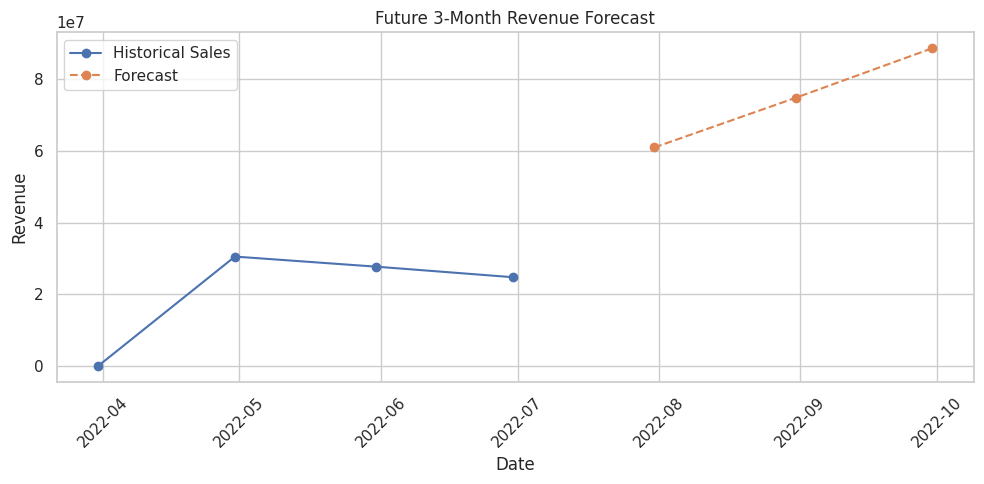

In [78]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["date"], monthly_sales["monthly_revenue"], marker='o', label="Historical Sales")
plt.plot(future_forecast["date"], future_forecast["predicted_revenue"], marker='o', linestyle='--', label="Forecast")
plt.title("Future 3-Month Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# ORDER CANCELLATION PREDICTION

In [80]:
# Create cancellation target

df["is_cancelled"] = df["status"].astype(str).str.contains("Cancelled", case=False, na=False).astype(int)

df["is_cancelled"].value_counts()

,count
is_cancelled,
0,110497
1,18311


In [81]:
feature_cols = ["fulfilment", "sales_channel", "ship_service_level", "category", "size", "courier_status", "qty", "amount", "b2b"]

clf_df = df[feature_cols + ["is_cancelled"]].copy()
clf_df["b2b"] = clf_df["b2b"].astype(int)

clf_df.head()

,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,amount,b2b,is_cancelled
0,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,647.62,0,1
1,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,406.00,0,0
2,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,329.00,1,0
3,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,753.33,0,1
4,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,574.00,0,0


In [82]:
label_encoders = {}

for col in clf_df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    clf_df[col] = le.fit_transform(clf_df[col].astype(str))
    label_encoders[col] = le

clf_df.head()

,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,amount,b2b,is_cancelled
0,1,0,1,5,7,1,0,647.62,0,1
1,1,0,1,2,0,2,1,406.00,0,0
2,0,0,0,2,8,2,1,329.00,1,0
3,1,0,1,0,5,1,0,753.33,0,1
4,0,0,0,6,0,2,1,574.00,0,0


In [83]:
X = clf_df.drop("is_cancelled", axis=1)
y = clf_df["is_cancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

(103046, 9) (25762, 9)
Logistic Regression Accuracy: 0.9959630463473332

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22100
           1       0.97      1.00      0.99      3662

    accuracy                           1.00     25762
   macro avg       0.99      1.00      0.99     25762
weighted avg       1.00      1.00      1.00     25762



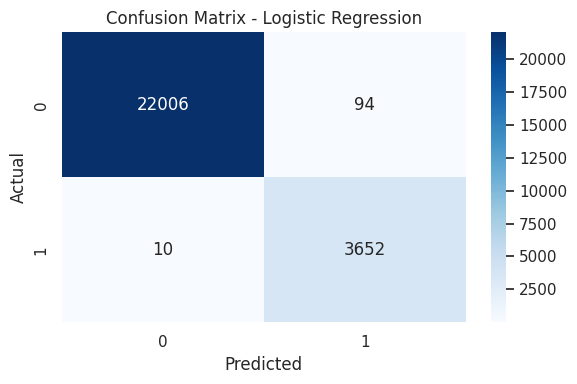

In [84]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Feature Importance / Coefficients:
courier_status         8.440590
b2b                    0.017651
size                   0.002202
amount                 0.000335
category              -0.005030
sales_channel         -2.754483
fulfilment            -2.860371
ship_service_level    -3.068970
qty                  -26.729860
dtype: float64


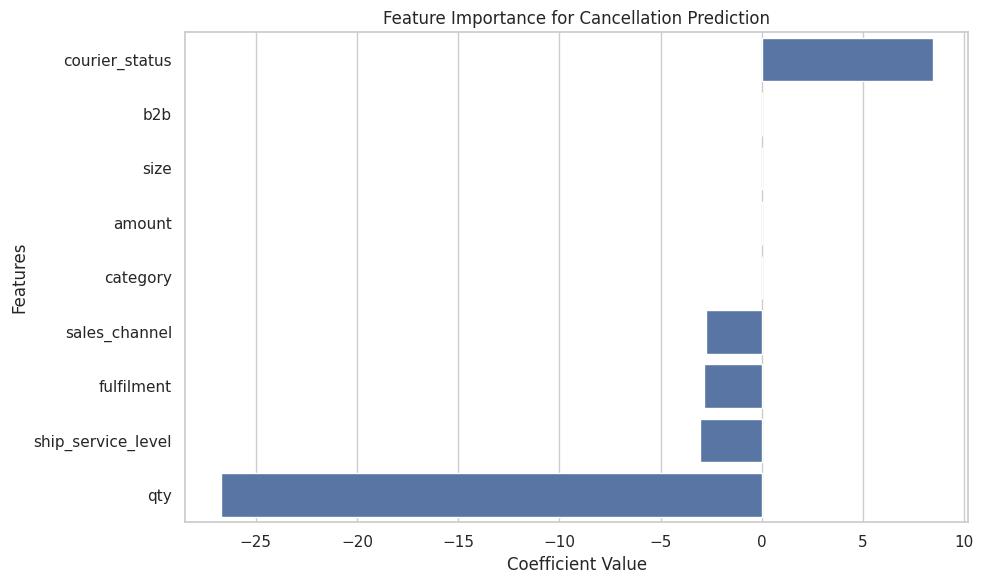

In [85]:
feature_importance = pd.Series(log_model.coef_[0], index=X.columns).sort_values(ascending=False)

print("Feature Importance / Coefficients:")
print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance for Cancellation Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

              Feature  Coefficient
5      courier_status     8.440590
8                 b2b     0.017651
4                size     0.002202
7              amount     0.000335
3            category    -0.005030
1       sales_channel    -2.754483
0          fulfilment    -2.860371
2  ship_service_level    -3.068970
6                 qty   -26.729860


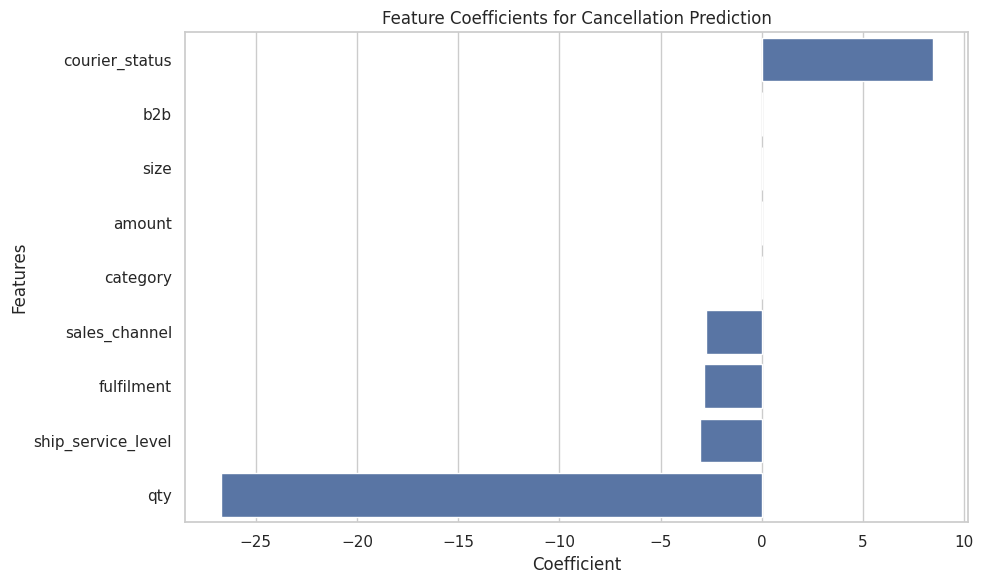

In [86]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df, x="Coefficient", y="Feature")
plt.title("Feature Coefficients for Cancellation Prediction")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [90]:
print("\n===== 12. FINAL CONCLUSION =====\n")

print("This project successfully analyzed Amazon sales data using data cleaning, visualization, business analysis, and optional machine learning techniques.")
print("The analysis identified sales trends, top-performing categories, regional performance, fulfillment efficiency, and customer behavior patterns.")
print("Additional machine learning models were used to perform customer segmentation, sales forecasting, and order cancellation prediction.")
print("Overall, the project provides useful business insights and practical recommendations to improve sales, delivery performance, and customer satisfaction.")



===== 12. FINAL CONCLUSION =====

This project successfully analyzed Amazon sales data using data cleaning, visualization, business analysis, and optional machine learning techniques.
The analysis identified sales trends, top-performing categories, regional performance, fulfillment efficiency, and customer behavior patterns.
Additional machine learning models were used to perform customer segmentation, sales forecasting, and order cancellation prediction.
Overall, the project provides useful business insights and practical recommendations to improve sales, delivery performance, and customer satisfaction.
